# Standardization with Scikit-learn

We'll use a package called Scikit-learn for standardization. Scikit-learn has many useful functions for data analysis and machine learning, i.e. learning patterns and making predictions from data.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

Functions in Scikit-learn follow 3 steps:
1. Initialize a Scikit-learn object with any desired specifications
2. "Fit" the object with a dataset. This involved estimating parameters from data. For z-standardization, it will calculate the mean and standard deviation.
3. Transform a dataset using the fitted object

In [2]:
penguins = sns.load_dataset('penguins')
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Let's initialize a Scikit-learn object to do the standardization for us.

In [3]:
penguins_scaler = StandardScaler()

Select continuous variables in the penguins dataset since standardization is only applied to continuous variables.

In [4]:
penguins_continous = penguins.select_dtypes('number').copy()
penguins_continous.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     342 non-null    float64
 1   bill_depth_mm      342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
dtypes: float64(4)
memory usage: 10.9 KB


Now let's fit the Scikit-learn `StandardScaler` object with a dataset.

In [5]:
penguins_scaler.fit(penguins_continous)

StandardScaler()

We can now transform the dataset into its standardized format.

In [6]:
penguins_std_arr = penguins_scaler.transform(penguins_continous)
penguins_std_arr.shape

(344, 4)

In [7]:
penguins_std = pd.DataFrame(penguins_std_arr, columns=penguins_continous.columns)
penguins_std

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.884499,0.785449,-1.418347,-0.564142
1,-0.811126,0.126188,-1.062250,-0.501703
2,-0.664380,0.430462,-0.421277,-1.188532
3,NaN,NaN,NaN,NaN
4,-1.324737,1.089724,-0.563715,-0.938776
...,...,...,...,...
339,NaN,NaN,NaN,NaN
340,0.527932,-1.445897,1.003109,0.809516
341,1.188289,-0.735923,1.501644,1.933419
342,0.234440,-1.192335,0.789451,1.246590


In [9]:
penguins_std.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,3.420000e+02,3.420000e+02,3.420000e+02,3.420000e+02
mean,8.310441e-17,-1.412775e-15,-8.310441e-16,4.155221e-17
std,1.001465e+00,1.001465e+00,1.001465e+00,1.001465e+00
min,-2.168526e+00,-2.054446e+00,-2.059320e+00,-1.875362e+00
25%,-8.615697e-01,-7.866355e-01,-7.773731e-01,-8.138982e-01
50%,9.686524e-02,7.547549e-02,-2.788381e-01,-1.895079e-01
75%,8.397670e-01,7.854492e-01,8.606705e-01,6.846384e-01
max,2.875868e+00,2.205397e+00,2.142618e+00,2.620248e+00


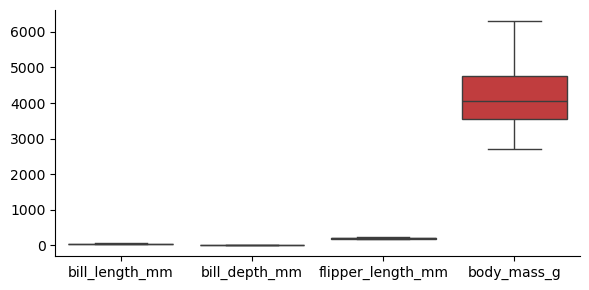

In [11]:
sns.catplot(data=penguins, kind='box', height=3, aspect=2)
plt.show()

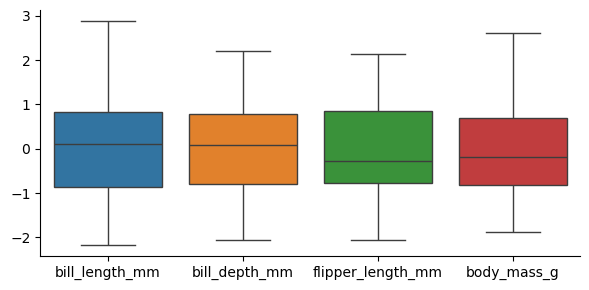

In [12]:
sns.catplot(data=penguins_std, kind='box', height=3, aspect=2)
plt.show()

Note that the shape of the distributions of these continuous variables have not changed with standardization.

In [13]:
penguins.columns

Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')

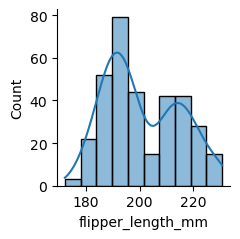

In [16]:
sns.displot(data=penguins, x='flipper_length_mm', kind='hist', kde=True, height=2.5)
plt.show()

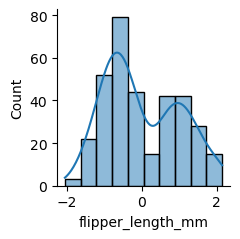

In [17]:
sns.displot(data=penguins_std, x='flipper_length_mm', kind='hist', kde=True, height=2.5)
plt.show()